In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

print("Loading dataset...")
data = fetch_kddcup99(subset=None, shuffle=True, random_state=42, percent10=False)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['label'] = data.target
df['label'] = df['label'].str.decode('utf-8')
print(f"Shape: {df.shape}")
df.head()

Loading dataset...
Shape: (4898431, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,b'udp',b'domain_u',b'SF',42,42,0,0,0,0,...,250,0.98,0.01,0.0,0.0,0.0,0.0,0.0,0.0,normal.
1,0,b'icmp',b'ecr_i',b'SF',520,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
2,0,b'tcp',b'http',b'SF',517,7131,0,0,0,0,...,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal.
3,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,smurf.
4,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,smurf.


In [2]:
print("Raw attack types:")
print(df['label'].value_counts())

Raw attack types:
label
smurf.              2807886
neptune.            1072017
normal.              972781
satan.                15892
ipsweep.              12481
portsweep.            10413
nmap.                  2316
back.                  2203
warezclient.           1020
teardrop.               979
pod.                    264
guess_passwd.            53
buffer_overflow.         30
land.                    21
warezmaster.             20
imap.                    12
rootkit.                 10
loadmodule.               9
ftp_write.                8
multihop.                 7
phf.                      4
perl.                     3
spy.                      2
Name: count, dtype: int64


In [3]:
LABEL_MAP = {
    'normal.': 'Normal',
    'back.': 'DoS', 'land.': 'DoS', 'neptune.': 'DoS',
    'pod.': 'DoS', 'smurf.': 'DoS', 'teardrop.': 'DoS',
    'ipsweep.': 'Probe', 'nmap.': 'Probe',
    'portsweep.': 'Probe', 'satan.': 'Probe',
    'ftp_write.': 'R2L', 'guess_passwd.': 'R2L', 'imap.': 'R2L',
    'multihop.': 'R2L', 'phf.': 'R2L', 'spy.': 'R2L',
    'warezclient.': 'R2L', 'warezmaster.': 'R2L',
    'buffer_overflow.': 'U2R', 'loadmodule.': 'U2R',
    'perl.': 'U2R', 'rootkit.': 'U2R'
}
df['attack_category'] = df['label'].map(LABEL_MAP)
df = df.dropna(subset=['attack_category'])
print("Attack categories:")
print(df['attack_category'].value_counts())

Attack categories:
attack_category
DoS       3883370
Normal     972781
Probe       41102
R2L          1126
U2R            52
Name: count, dtype: int64


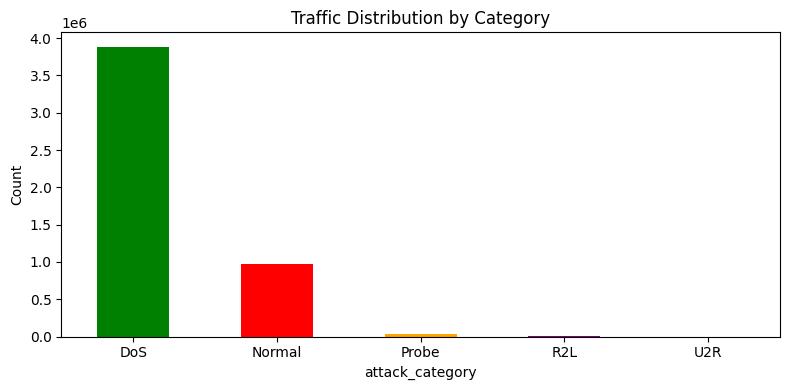

In [4]:
import matplotlib.pyplot as plt

df['attack_category'].value_counts().plot(
    kind='bar', color=['green','red','orange','purple','blue'],
    figsize=(8,4), title='Traffic Distribution by Category'
)
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/distribution.png')
plt.show()